<a href="https://colab.research.google.com/github/hamza16071/Sentiment_Analysis/blob/main/Sentiment_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

In [ ]:
df = pd.read_csv('/content/IMDB Dataset.zip')

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
encoder = LabelEncoder()

df['sentiment'] = encoder.fit_transform(df['sentiment'])

In [ ]:
X = df['review']
y = df['sentiment']

In [ ]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

In [ ]:
X_pad = pad_sequences(X_seq, maxlen=200)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rnn_model = Sequential()

rnn_model.add(Embedding(input_dim=5000, output_dim=128))

rnn_model.add(SimpleRNN(64))

rnn_model.add(Dense(1, activation='sigmoid'))

In [ ]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.7077 - loss: 0.5478 - val_accuracy: 0.7937 - val_loss: 0.4525
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - accuracy: 0.8544 - loss: 0.3479 - val_accuracy: 0.8325 - val_loss: 0.4105
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9004 - loss: 0.2535 - val_accuracy: 0.8491 - val_loss: 0.3926
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9367 - loss: 0.1742 - val_accuracy: 0.8270 - val_loss: 0.4662
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 0.9690 - loss: 0.0926 - val_accuracy: 0.8087 - val_loss: 0.5867


In [ ]:
rnn_pred = rnn_model.predict(X_test)

rnn_pred = (rnn_pred > 0.5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


In [ ]:
print(classification_report(y_test, rnn_pred))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      4961
           1       0.80      0.85      0.82      5039

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



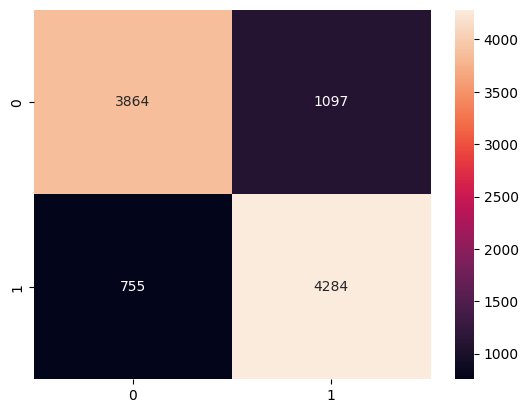

In [ ]:
cm = confusion_matrix(y_test, rnn_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

In [ ]:
lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=5000, output_dim=128))

lstm_model.add(LSTM(64))

lstm_model.add(Dense(1, activation='sigmoid'))

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 111s 217ms/step - accuracy: 0.8158 - loss: 0.4029 - val_accuracy: 0.8665 - val_loss: 0.3140
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 210ms/step - accuracy: 0.8916 - loss: 0.2693 - val_accuracy: 0.8845 - val_loss: 0.2771
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 210ms/step - accuracy: 0.8941 - loss: 0.2534 - val_accuracy: 0.8654 - val_loss: 0.3271
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 209ms/step - accuracy: 0.9204 - loss: 0.2018 - val_accuracy: 0.8770 - val_loss: 0.3574
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 209ms/step - accuracy: 0.9424 - loss: 0.1546 - val_accuracy: 0.8819 - val_loss: 0.3285


In [ ]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = (lstm_pred > 0.5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


In [ ]:
print(classification_report(y_test, lstm_pred))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88      4961
           1       0.86      0.91      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
rnn_acc = accuracy_score(y_test, rnn_pred)

lstm_acc = accuracy_score(y_test, lstm_pred)

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)

RNN Accuracy: 0.8148
LSTM Accuracy: 0.8804


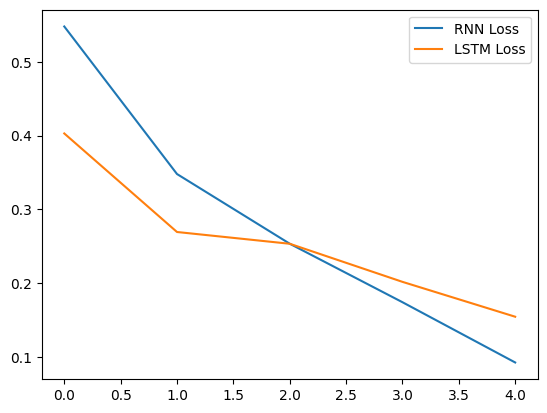

In [ ]:
plt.plot(rnn_history.history['loss'], label='RNN Loss')

plt.plot(lstm_history.history['loss'], label='LSTM Loss')

plt.legend()

plt.show()

In [ ]:
def predict_sentiment(review):

    # convert text into sequence
    sequence = tokenizer.texts_to_sequences([review])

    # padding
    padded = pad_sequences(sequence, maxlen=200)

    # prediction
    prediction = lstm_model.predict(padded)

    # result
    if prediction[0][0] > 0.5:
        print("Positive Review 😊")
    else:
        print("Negative Review 😡")

In [ ]:
predict_sentiment("This movie was absolutely fantastic and amazing")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Positive Review 😊


In [ ]:
predict_sentiment("Worst movie ever, complete waste of time")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Negative Review 😡


In [ ]:
user_review = input("Enter your movie review: ")

predict_sentiment(user_review)

Enter your movie review: start is awesome but end is aweful
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Positive Review 😊
